# Numerical Methods 
# Bisection Method

## Learning Objectives
1. Implement Bisection Method from scratch.
2. Derive theoretical error bound.
3. Perform convergence and error analysis.
4. Compare stopping criteria.
5. Analyze failure conditions.


## Theoretical Background

For a continuous function $f(x)$ on $[a,b]$ such that $f(a)f(b) < 0$,
there exists at least one root in $(a,b)$.

At iteration n:

$$x_n = \frac{a_n + b_n}{2}$$

### Error Bound

$$|x_n - \alpha| \leq \frac{b-a}{2^n}$$

where α is the exact root.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Implement General Bisection Function
Include three stopping criteria:
1. |f(x)| < tolerance
2. |b-a| < tolerance
3. Maximum iterations reached

In [2]:
def bisection(f, a, b, tol=1e-6, max_iter=100):
    if f(a)*f(b) >= 0:
        raise ValueError('Invalid interval: f(a) and f(b) must have opposite signs.')

    iterations = []

    for n in range(1, max_iter+1):
        c = (a + b) / 2
        iterations.append((n, a, b, c, f(c)))

        if abs(f(c)) < tol or abs(b - a) < tol:
            return c, iterations

        if f(a)*f(c) < 0:
            b = c
        else:
            a = c

    return c, iterations

Solve:
$$x^3 - 2x - 5 = 0$$
on interval [2,3]

In [3]:
def f1(x):
    return x**3 - 2*x - 5

root1, data1 = bisection(f1, 2, 3)
root1

2.0945515632629395

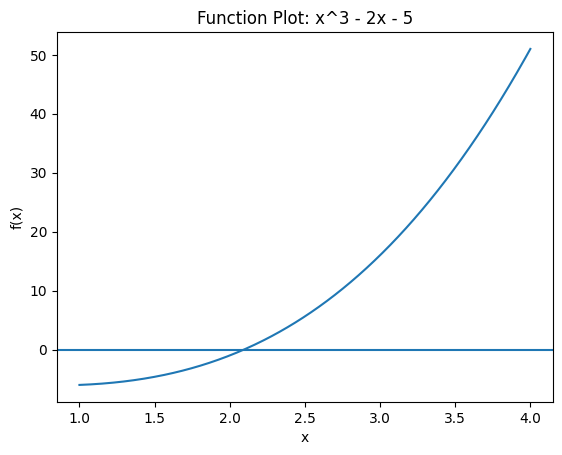

In [4]:
x = np.linspace(1, 4, 400)
y = f1(x)

plt.figure()
plt.plot(x, y)
plt.axhline(0)
plt.title('Function Plot: x^3 - 2x - 5')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

Verify theoretical error bound numerically.

Compare actual error vs theoretical bound.

In [5]:
exact_root = root1
a = 2
b = 3
errors = []
bounds = []

for n in range(1, 11):
    c = (a + b)/2
    errors.append(abs(c - exact_root))
    bounds.append((3-2)/(2**n))

    if f1(a)*f1(c) < 0:
        b = c
    else:
        a = c

errors, bounds

([0.40544843673706055,
  0.15544843673706055,
  0.030448436737060547,
  0.03205156326293945,
  0.0008015632629394531,
  0.014823436737060547,
  0.007010936737060547,
  0.003104686737060547,
  0.0011515617370605469,
  0.00017499923706054688],
 [0.5,
  0.25,
  0.125,
  0.0625,
  0.03125,
  0.015625,
  0.0078125,
  0.00390625,
  0.001953125,
  0.0009765625])

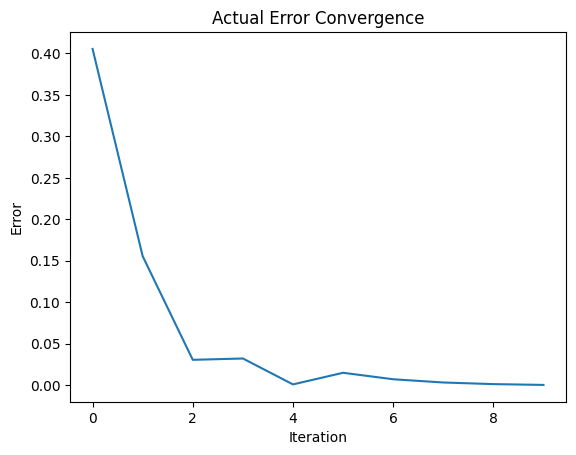

In [6]:
plt.figure()
plt.plot(errors)
plt.title('Actual Error Convergence')
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.show()

Try solving:
$
x^2 + 1 = 0
$

In [7]:
def f_fail(x):
    return x**2 + 1

# Uncomment below to observe behavior
# bisection(f_fail, -2, 2)